# Exploration: Time Stamps

Parsing the timestamps and understanding them

In [20]:
import json
import pandas as pd
import matplotlib.pyplot as plt 
from pathlib import Path
from anomaly_detection.etl.load import load_timestamps, load_timestamps_df

plt.style.use('ggplot')

In [21]:
# Path to the data
project_folder = Path.cwd().parent

evtx_path = project_folder / "data/raw/93_securitelog.evtx"

evtx_path

WindowsPath('c:/Users/hp/Documents/School/anomaly-detection/data/raw/93_securitelog.evtx')

In [22]:
output_path = project_folder / "outputs/time_exploration"

output_path

WindowsPath('c:/Users/hp/Documents/School/anomaly-detection/outputs/time_exploration')

In [23]:
timestamps = load_timestamps(evtx_path)
len(timestamps)

31466

In [24]:
timestamps_df = load_timestamps_df(evtx_path)

timestamps_df.head(10)

,timestamp,minute,minute_of_hour,hour,hour_of_day,deltatime
0,2026-06-17 00:15:07.799169600+00:00,2026-06-17 00:15:00+00:00,15,2026-06-17 00:00:00+00:00,0,NaT
1,2026-06-17 00:15:08.470381900+00:00,2026-06-17 00:15:00+00:00,15,2026-06-17 00:00:00+00:00,0,0 days 00:00:00.671212300
2,2026-06-17 00:15:55.134677300+00:00,2026-06-17 00:15:00+00:00,15,2026-06-17 00:00:00+00:00,0,0 days 00:00:46.664295400
3,2026-06-17 00:16:00.615230500+00:00,2026-06-17 00:16:00+00:00,16,2026-06-17 00:00:00+00:00,0,0 days 00:00:05.480553200
4,2026-06-17 00:16:00.615938600+00:00,2026-06-17 00:16:00+00:00,16,2026-06-17 00:00:00+00:00,0,0 days 00:00:00.000708100
5,2026-06-17 00:16:00.615964300+00:00,2026-06-17 00:16:00+00:00,16,2026-06-17 00:00:00+00:00,0,0 days 00:00:00.000025700
6,2026-06-17 00:16:00.615972300+00:00,2026-06-17 00:16:00+00:00,16,2026-06-17 00:00:00+00:00,0,0 days 00:00:00.000008
7,2026-06-17 00:16:02.763079500+00:00,2026-06-17 00:16:00+00:00,16,2026-06-17 00:00:00+00:00,0,0 days 00:00:02.147107200
8,2026-06-17 00:16:02.764530600+00:00,2026-06-17 00:16:00+00:00,16,2026-06-17 00:00:00+00:00,0,0 days 00:00:00.001451100
9,2026-06-17 00:16:02.765740100+00:00,2026-06-17 00:16:00+00:00,16,2026-06-17 00:00:00+00:00,0,0 days 00:00:00.001209500


In [25]:
# Export timestamps_df to csv and describe it
timestamps_df.to_csv(project_folder / "data/processed/timestamps.csv", index=False)

timestamps_df.describe(include='all')

,timestamp,minute,minute_of_hour,hour,hour_of_day,deltatime
count,31465,31465,31465.000000,31465,31465.000000,31464
mean,2026-06-17 05:05:01.975473664+00:00,2026-06-17 05:04:58.974098176+00:00,25.636326,2026-06-17 04:39:20.794533888+00:00,4.655776,0 days 00:00:01.096776246
min,2026-06-17 00:15:07.799169600+00:00,2026-06-17 00:15:00+00:00,0.000000,2026-06-17 00:00:00+00:00,0.000000,0 days 00:00:00.000000400
25%,2026-06-17 02:42:24.546088192+00:00,2026-06-17 02:42:00+00:00,10.000000,2026-06-17 02:00:00+00:00,2.000000,0 days 00:00:00.000024300
50%,2026-06-17 05:02:00.627089920+00:00,2026-06-17 05:02:00+00:00,28.000000,2026-06-17 05:00:00+00:00,5.000000,0 days 00:00:00.000428900
75%,2026-06-17 07:30:00.962312704+00:00,2026-06-17 07:30:00+00:00,40.000000,2026-06-17 07:00:00+00:00,7.000000,0 days 00:00:00.002838550
max,2026-06-17 09:50:16.766986300+00:00,2026-06-17 09:50:00+00:00,59.000000,2026-06-17 09:00:00+00:00,9.000000,0 days 00:01:49.778573400
std,NaN,NaN,17.605981,NaN,2.770680,0 days 00:00:08.054596820


In [26]:
# Count events per minute and events per hour for plotting
events_per_minute = (
    timestamps_df
    .groupby("minute")
    .size()
    .rename("events")
    .reset_index()
)

events_per_hour = (
    timestamps_df
    .groupby("hour")
    .size()
    .rename("events")
    .reset_index()
)

events_per_hour

,hour,events
0,2026-06-17 00:00:00+00:00,2023
1,2026-06-17 01:00:00+00:00,3294
2,2026-06-17 02:00:00+00:00,3289
3,2026-06-17 03:00:00+00:00,3304
4,2026-06-17 04:00:00+00:00,3275
5,2026-06-17 05:00:00+00:00,3289
6,2026-06-17 06:00:00+00:00,3289
7,2026-06-17 07:00:00+00:00,3292
8,2026-06-17 08:00:00+00:00,3303
9,2026-06-17 09:00:00+00:00,3107


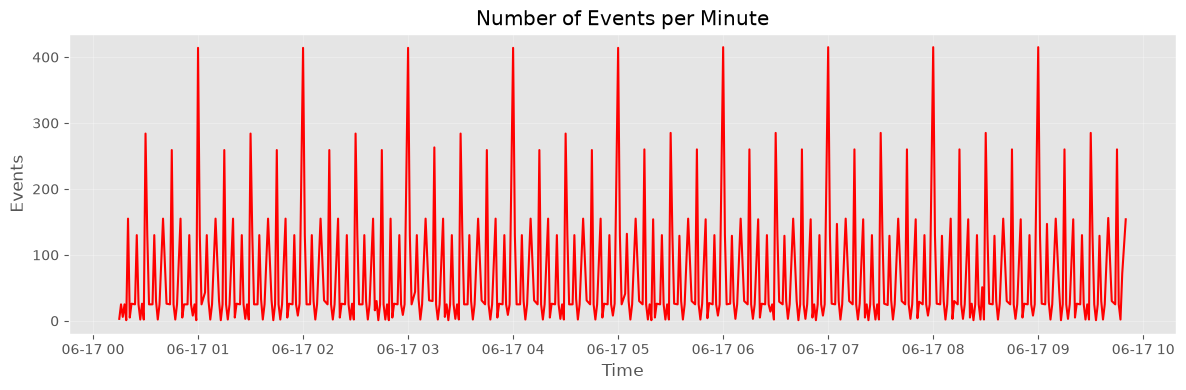

In [27]:
plt.figure(figsize=(12, 4))

plt.plot(
    events_per_minute["minute"],
    events_per_minute["events"],
    color="red"
)

plt.title("Number of Events per Minute")
plt.xlabel("Time")
plt.ylabel("Events")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(output_path / "events_per_minute.png")

plt.show()

In [28]:
events_by_minute_of_hour = (
    timestamps_df
    .groupby("minute_of_hour")
    .size()
    .reindex(range(60), fill_value=0)
    .rename("events")
    .reset_index()
)

events_by_hour_of_day = (
    timestamps_df
    .groupby("hour_of_day")
    .size()
    .reindex(range(24), fill_value=0)
    .rename("events")
    .reset_index()
)

events_by_hour_of_day

,hour_of_day,events
0,0,2023
1,1,3294
2,2,3289
3,3,3304
4,4,3275
5,5,3289
6,6,3289
7,7,3292
8,8,3303
9,9,3107


In [29]:
events_by_minute_of_hour_dict = events_by_minute_of_hour.to_dict(orient='records')

events_by_minute_of_hour_dict = [{str(record['minute_of_hour']).zfill(2): record['events']} for record in events_by_minute_of_hour_dict]

with open(output_path / "events_per_minutes_of_hour.txt", "w", encoding="utf-8") as file:
    file.write(json.dumps(
        events_by_minute_of_hour_dict,
        indent=4
    ))

events_by_minute_of_hour_dict

[{'00': 3730},
 {'01': 1170},
 {'02': 228},
 {'03': 0},
 {'04': 279},
 {'05': 1204},
 {'06': 271},
 {'07': 19},
 {'08': 225},
 {'09': 0},
 {'10': 1395},
 {'11': 3},
 {'12': 287},
 {'13': 2},
 {'14': 230},
 {'15': 2343},
 {'16': 250},
 {'17': 27},
 {'18': 251},
 {'19': 2},
 {'20': 1545},
 {'21': 51},
 {'22': 258},
 {'23': 3},
 {'24': 250},
 {'25': 1300},
 {'26': 250},
 {'27': 35},
 {'28': 278},
 {'29': 20},
 {'30': 2845},
 {'31': 1300},
 {'32': 257},
 {'33': 1},
 {'34': 249},
 {'35': 1295},
 {'36': 307},
 {'37': 21},
 {'38': 251},
 {'39': 0},
 {'40': 1551},
 {'41': 16},
 {'42': 299},
 {'43': 3},
 {'44': 250},
 {'45': 2595},
 {'46': 250},
 {'47': 23},
 {'48': 298},
 {'49': 1},
 {'50': 1545},
 {'51': 43},
 {'52': 236},
 {'53': 1},
 {'54': 225},
 {'55': 1170},
 {'56': 225},
 {'57': 74},
 {'58': 227},
 {'59': 1}]

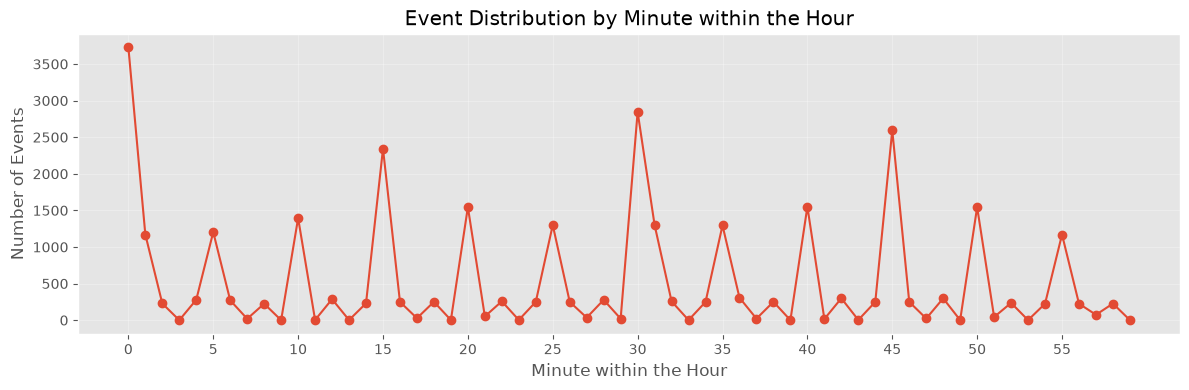

In [30]:
plt.figure(figsize=(12, 4))

plt.plot(
    events_by_minute_of_hour["minute_of_hour"],
    events_by_minute_of_hour["events"],
    marker="o"
)

plt.xticks(range(0, 60, 5))
plt.xlabel("Minute within the Hour")
plt.ylabel("Number of Events")
plt.title("Event Distribution by Minute within the Hour")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(output_path / "events_per_minute_of_hour.png")

plt.show()

In [31]:
largest_deltatimes_df = timestamps_df.nlargest(
    20,
    "deltatime"
)[["timestamp", "deltatime"]]

largest_deltatimes_df

,timestamp,deltatime
19256,2026-06-17 06:10:00.529593600+00:00,0 days 00:01:49.778573400
20841,2026-06-17 06:40:00.523547500+00:00,0 days 00:01:49.754916100
14785,2026-06-17 04:50:00.520666200+00:00,0 days 00:01:49.696035900
21365,2026-06-17 06:50:00.531217200+00:00,0 days 00:01:49.678182400
15754,2026-06-17 05:04:00.625883200+00:00,0 days 00:01:49.639028
4917,2026-06-17 01:50:00.528371100+00:00,0 days 00:01:49.634212700
7455,2026-06-17 02:34:00.611858900+00:00,0 days 00:01:49.584930600
14263,2026-06-17 04:40:00.529641700+00:00,0 days 00:01:49.570699800
5886,2026-06-17 02:04:00.620926700+00:00,0 days 00:01:49.541742900
17708,2026-06-17 05:42:00.617131+00:00,0 days 00:01:49.538597500


In [32]:
largest_deltatimes_df.iloc[0, :]

i = int(largest_deltatimes_df.iloc[0, :].name)

burst_example_df = timestamps_df.loc[i-5:i+5, ["timestamp", "deltatime"]]

burst_example_df.to_csv(output_path / "burst_example.csv")

burst_example_df

,timestamp,deltatime
19251,2026-06-17 06:08:03.432371900+00:00,0 days 00:00:00.666826600
19252,2026-06-17 06:08:03.471966500+00:00,0 days 00:00:00.039594600
19253,2026-06-17 06:08:03.482253500+00:00,0 days 00:00:00.010287
19254,2026-06-17 06:08:03.704851200+00:00,0 days 00:00:00.222597700
19255,2026-06-17 06:08:10.751020200+00:00,0 days 00:00:07.046169
19256,2026-06-17 06:10:00.529593600+00:00,0 days 00:01:49.778573400
19257,2026-06-17 06:10:00.530640200+00:00,0 days 00:00:00.001046600
19258,2026-06-17 06:10:00.530666300+00:00,0 days 00:00:00.000026100
19259,2026-06-17 06:10:00.530674200+00:00,0 days 00:00:00.000007900
19260,2026-06-17 06:10:00.531154700+00:00,0 days 00:00:00.000480500
